# Restricted Model Fit — Person 0

Fits the soft-margin Model A on the **cleanest subset** of person 0's queries:

- **Remove** any trial with RT > 30s (slow response — likely deliberating, not decisive)
- **Remove** all trials of any query answered inconsistently across sessions (person flipped)

What remains is the set of queries where person 0 was fast **and** always gave the same answer — the most unambiguously decisive responses.

Goal: check whether the best-fit parameters change when we restrict to this high-confidence subset, and whether parameter uncertainty (near-optimal set) tightens.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

df = pd.read_csv('boerstler_data_labeled.csv', index_col=0)

DIFF_COLS = ['alcodiff', 'depdiff', 'lifediff', 'crimdiff']
ATTR      = ['alco', 'dep', 'life', 'crim']
RAW_MAX   = np.array([df[c].abs().max() for c in DIFF_COLS], dtype=float)

P_NOISE = 0.10
A = np.log(2 * (1 - P_NOISE))   # +0.588 per decisive-correct
B = np.log(2 * P_NOISE)          # −1.609 per decisive-error
print(f'p_noise={P_NOISE}  A={A:.3f}  B={B:.3f}  C={-B/A:.2f}')


p_noise=0.1  A=0.588  B=-1.609  C=2.74


In [2]:
# ── Build restricted dataset ─────────────────────────────────────────────────
RT_CUTOFF = 30   # seconds

p0 = df[df['person_id'] == 0].sort_index().copy()
p0['query'] = list(zip(*[p0[c] for c in DIFF_COLS]))

# Filter 1: slow trials (RT > 30s)
slow_mask = p0['secElasped'] > RT_CUTOFF

# Filter 2: inconsistently-answered queries (any query answered both L and R across sessions)
query_choices  = p0.groupby('query')['chosen'].apply(set)
flipped        = set(query_choices[query_choices.map(len) > 1].index)
flipped_mask   = p0['query'].isin(flipped)

# Keep: fast AND consistent
keep = (~slow_mask) & (~flipped_mask)
p0_clean = p0[keep].copy()

print('── Filter summary ────────────────────────────────────────────────')
print(f'Total trials (person 0, all 10 sessions): {len(p0)}')
print(f'  Removed — RT > {RT_CUTOFF}s:                     {slow_mask.sum():>4} trials '
      f'({p0[slow_mask]["query"].nunique()} unique queries)')
print(f'  Removed — inconsistent queries:           {(~slow_mask & flipped_mask).sum():>4} additional trials '
      f'({len(flipped)} queries, {flipped_mask.sum()} trials total, '
      f'{(slow_mask & flipped_mask).sum()} already excluded above)')
print(f'  Kept (fast + consistent):                 {keep.sum():>4} trials '
      f'({p0_clean["query"].nunique()} unique queries)')
print()

# Build c, d, y arrays
c_full  = p0[DIFF_COLS].values / RAW_MAX
d_full  = np.abs(c_full)
y_full  = p0['chosen'].values.astype(int)

c_clean = p0_clean[DIFF_COLS].values / RAW_MAX
d_clean = np.abs(c_clean)
y_clean = p0_clean['chosen'].values.astype(int)

print(f'Full dataset:        n={len(y_full)},  chose_left={y_full.sum()},  chose_right={(1-y_full).sum()}')
print(f'Restricted dataset:  n={len(y_clean)},  chose_left={y_clean.sum()},  chose_right={(1-y_clean).sum()}')

removed = (~keep).values  # boolean mask over 600 full trials


── Filter summary ────────────────────────────────────────────────
Total trials (person 0, all 10 sessions): 600
  Removed — RT > 30s:                       47 trials (42 unique queries)
  Removed — inconsistent queries:             59 additional trials (19 queries, 66 trials total, 7 already excluded above)
  Kept (fast + consistent):                  494 trials (281 unique queries)

Full dataset:        n=600,  chose_left=297,  chose_right=303
Restricted dataset:  n=494,  chose_left=250,  chose_right=244


In [3]:
# ── Helpers (ported from new_model_fitting) ──────────────────────────────────

def simplex_grid(m, k):
    def _gen(rem, dims):
        if dims == 1: yield (rem,); return
        for v in range(rem + 1):
            for rest in _gen(rem - v, dims - 1): yield (v,) + rest
    return np.array(list(_gen(k, m)), dtype=float) / k

def count_dc_de(labels, y):
    dc = int(((labels== 1)&(y==1)).sum() + ((labels==-1)&(y==0)).sum())
    de = int(((labels== 1)&(y==0)).sum() + ((labels==-1)&(y==1)).sum())
    return dc, de

def _wedge_boundaries(tau_r, tau_kappa, x_max=1.05):
    apex_x, apex_y = tau_r / 2, tau_r / 2
    if tau_kappa >= 1.0 - 1e-6:
        return (np.array([apex_x, apex_x]), np.array([apex_y, x_max*5])), \
               (np.array([apex_x, x_max]),  np.array([apex_y, apex_y]))
    m_up = (1 + tau_kappa) / (1 - tau_kappa)
    m_lo = (1 - tau_kappa) / (1 + tau_kappa)
    xs   = np.linspace(apex_x, x_max, 200)
    return (xs, m_up*xs - tau_kappa*tau_r/(1-tau_kappa)), \
           (xs, m_lo*xs + tau_kappa*tau_r/(1+tau_kappa))

OMEGA_GRID = simplex_grid(4, k=10)
TAU_K_VALS = np.arange(0, 1.0, 0.1)
print(f'Grid: {len(OMEGA_GRID)} ω points, {len(TAU_K_VALS)} τ_κ values')


Grid: 286 ω points, 10 τ_κ values


In [4]:
# ── Soft-margin fit on full and restricted datasets ───────────────────────────

def fit_soft(c_mat, d_mat, y, label=''):
    results = []
    cls     = {}
    for omega in OMEGA_GRID:
        r     = d_mat @ omega
        kappa = c_mat @ omega
        for tau_r in np.concatenate([[0.0], np.sort(np.unique(r))]):
            for tau_k in TAU_K_VALS:
                w   = tau_k * np.maximum(0.0, r - tau_r)
                lab = np.zeros(len(y), dtype=np.int8)
                lab[(r >= tau_r) & ( kappa > w)] =  1
                lab[(r >= tau_r) & (-kappa > w)] = -1
                dc, de = count_dc_de(lab, y)
                score  = dc * A + de * B
                results.append(dict(omega=omega.copy(), tau_r=tau_r, tau_kappa=tau_k,
                                    dc=dc, de=de, score=score, labels=lab.copy()))
                key = lab.tobytes()
                if key not in cls:
                    cls[key] = dict(labels=lab.copy(), dc=dc, de=de,
                                    score=score, triples=[])
                cls[key]['triples'].append((omega.copy(), tau_r, tau_k))
    results.sort(key=lambda x: -x['score'])
    print(f'{label}: {len(results)} triples, {len(cls)} equivalence classes')
    return results, cls


t0 = time.time()
print('Fitting full dataset...')
res_full, cls_full = fit_soft(c_full, d_full, y_full, 'Full (600 trials)')

print('Fitting restricted dataset...')
res_rest, cls_rest = fit_soft(c_clean, d_clean, y_clean, f'Restricted ({len(y_clean)} trials)')
print(f'Fitting done in {time.time()-t0:.0f}s')


Fitting full dataset...
Full (600 trials): 66600 triples, 30855 equivalence classes
Fitting restricted dataset...
Restricted (494 trials): 66570 triples, 30660 equivalence classes
Fitting done in 5s


Bradley-Terry (corrected signs)  —  600 trials, person 0
-------------------------------------------------------
  beta (raw):              [1.791 6.968 4.801 4.442]
  beta (simplex-projected): [0.1   0.387 0.267 0.247]
  log-likelihood:          -121.891
  accuracy:                0.912

  Soft-margin omega:       [0.3 0.  0.1 0.6]
  Min-kappa-flip omega:    [0.1 0.3 0.6 0. ]


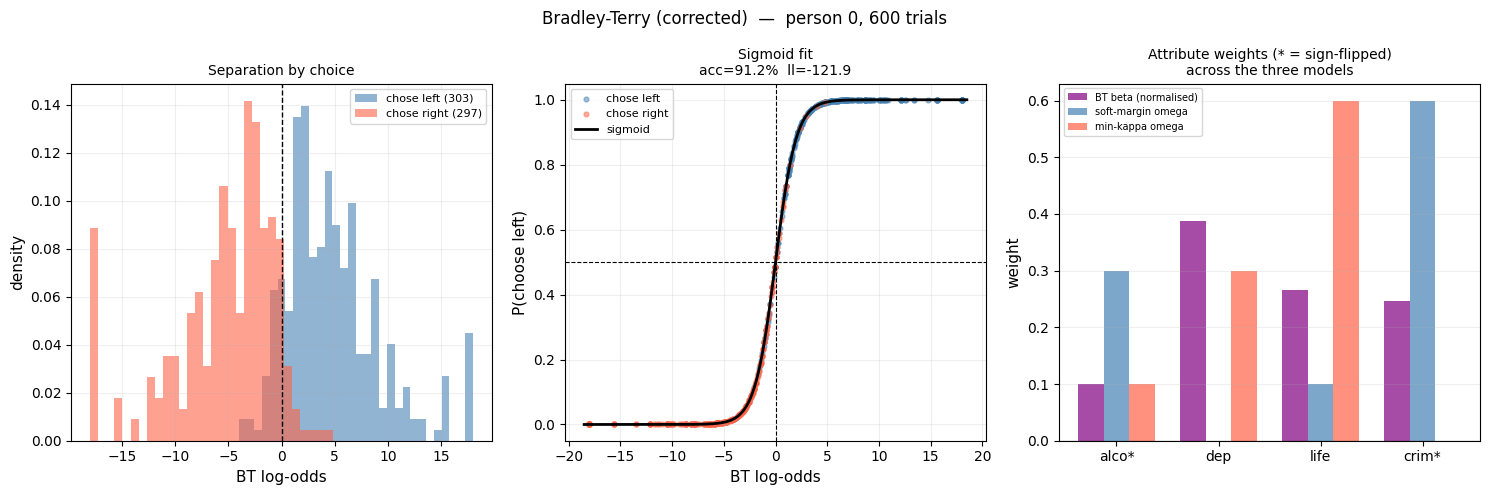

Saved bradley_terry_corrected.png


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# ── Bradley-Terry (corrected sign conventions) ───────────────────────────────
# Corrections applied:
#   1. choice 0 = left → y_bt = (chosen == 0)
#   2. alco and crim are 'lower = better', so negate their diffs so
#      higher transformed diff always means 'left is a better candidate'

SIGN = np.array([-1., 1., 1., -1.])   # [alco, dep, life, crim]
c_bt  = c_full * SIGN                  # flip alco and crim
y_bt  = (y_full == 0).astype(int)      # 1 = chose left

bt2 = LogisticRegression(fit_intercept=False, C=1e6, max_iter=1000)
bt2.fit(c_bt, y_bt)
beta2  = bt2.coef_[0]
probs2 = bt2.predict_proba(c_bt)[:, 1]
ll2    = -log_loss(y_bt, probs2, normalize=False)
acc2   = bt2.score(c_bt, y_bt)

# Project onto simplex: clip negatives then normalise
beta2_pos  = np.maximum(beta2, 0)
beta2_norm = beta2_pos / beta2_pos.sum() if beta2_pos.sum() > 0 else beta2_pos

print('Bradley-Terry (corrected signs)  —  600 trials, person 0')
print('-' * 55)
print(f'  beta (raw):              {np.round(beta2, 3)}')
print(f'  beta (simplex-projected): {np.round(beta2_norm, 3)}')
print(f'  log-likelihood:          {ll2:.3f}')
print(f'  accuracy:                {acc2:.3f}')
print()
print(f'  Soft-margin omega:       {np.round(omega_best, 2)}')
print(f'  Min-kappa-flip omega:    {np.round(omega_flip, 2)}')

logodds2 = c_bt @ beta2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Bradley-Terry (corrected)  —  person 0, 600 trials', fontsize=12)

# Panel 1: histogram separation
axes[0].hist(logodds2[y_bt==1], bins=30, alpha=0.6, color='steelblue',
             density=True, label='chose left ({})'.format((y_bt==1).sum()))
axes[0].hist(logodds2[y_bt==0], bins=30, alpha=0.6, color='tomato',
             density=True, label='chose right ({})'.format((y_bt==0).sum()))
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_xlabel('BT log-odds', fontsize=11)
axes[0].set_ylabel('density', fontsize=11)
axes[0].set_title('Separation by choice', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# Panel 2: sigmoid
xs = np.linspace(logodds2.min()-0.5, logodds2.max()+0.5, 300)
axes[1].scatter(logodds2[y_bt==1], probs2[y_bt==1], c='steelblue', s=12, alpha=0.5, label='chose left')
axes[1].scatter(logodds2[y_bt==0], probs2[y_bt==0], c='tomato',    s=12, alpha=0.5, label='chose right')
axes[1].plot(xs, 1/(1+np.exp(-xs)), 'k-', lw=2, label='sigmoid')
axes[1].axvline(0, color='black', lw=0.8, ls='--')
axes[1].axhline(0.5, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('BT log-odds', fontsize=11)
axes[1].set_ylabel('P(choose left)', fontsize=11)
axes[1].set_title('Sigmoid fit\nacc={:.1%}  ll={:.1f}'.format(acc2, ll2), fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

# Panel 3: weight comparison
attrs = ['alco*', 'dep', 'life', 'crim*']
x = np.arange(len(attrs))
w = 0.25
axes[2].bar(x - w, beta2 / np.abs(beta2).sum(), width=w,
            label='BT beta (normalised)', color='purple', alpha=0.7)
axes[2].bar(x,     omega_best, width=w,
            label='soft-margin omega',   color='steelblue', alpha=0.7)
axes[2].bar(x + w, omega_flip, width=w,
            label='min-kappa omega',     color='tomato', alpha=0.7)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(attrs, fontsize=10)
axes[2].set_ylabel('weight', fontsize=11)
axes[2].set_title('Attribute weights (* = sign-flipped)\nacross the three models', fontsize=10)
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('bradley_terry_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bradley_terry_corrected.png')


In [ ]:
# ── Smooth BT: P(choose left) = σ(B(s) · d) ─────────────────────────────────
#
# Standard BT:  P = σ(d)   where  d = c_bt @ β  (log-ratio of ratings)
# Smooth BT:    P = σ(B(s) · d)  with  B(s) = β₀ + β₁ log(s)
#
# Idea: discriminability B(s) depends on the total scale s = r_left + r_right.
# If β₁ < 0, high-scale pairs are noisier (less decisive);
# if β₁ > 0, high-scale pairs are more decisive.
#
# d and s come from the BT ratings above (beta2 fixed from c_bt2).
# We only fit (β₀, β₁) here — how discriminability varies with scale.

from scipy.optimize import minimize
from scipy.special import expit

# ── Compute ratings and features ──────────────────────────────────────────────
L_norm = (p0[['lalco','ldep','llife','lcrim']].values / RAW_MAX) * SIGN
R_norm = (p0[['ralco','rdep','rlife','rcrim']].values / RAW_MAX) * SIGN

r_left_  = np.exp(L_norm @ beta2)     # BT rating for left item
r_right_ = np.exp(R_norm @ beta2)     # BT rating for right item
d_       = np.log(r_left_) - np.log(r_right_)   # = c_bt @ beta2 = logodds2
s_       = r_left_ + r_right_                    # total scale

print(f's  range: [{s_.min():.4f}, {s_.max():.4f}]  median={np.median(s_):.4f}')
print(f'd  range: [{d_.min():.3f}, {d_.max():.3f}]')
print(f'Verify: max |d - logodds2| = {np.abs(d_ - logodds2).max():.2e}  (should be ~0)')

# ── NLL and gradient ──────────────────────────────────────────────────────────
def nll(beta):
    z = (beta[0] + beta[1] * np.log(s_)) * d_
    return float(np.sum(np.logaddexp(0, z) - y_bt * z))

def nll_grad(beta):
    B     = beta[0] + beta[1] * np.log(s_)
    z     = B * d_
    resid = expit(z) - y_bt          # shape (T,)
    return np.array([resid @ d_,
                     resid @ (np.log(s_) * d_)])

# ── Fit ───────────────────────────────────────────────────────────────────────
res_sbt = minimize(nll, [1.0, 0.0], jac=nll_grad, method='L-BFGS-B',
                   options={'ftol': 1e-15, 'gtol': 1e-8, 'maxiter': 2000})
b0, b1    = res_sbt.x
ll_smooth = -res_sbt.fun
grad_norm = np.linalg.norm(nll_grad(res_sbt.x))

# ── Comparison ────────────────────────────────────────────────────────────────
print()
print('─── Model comparison ─────────────────────────────────────────────')
print(f'{"Model":<22}  {"log-lik":>9}  {"#params":>7}  {"AIC":>8}')
print(f'{"Flat BT":<22}  {ll2:>9.3f}  {"4":>7}  {(-2*ll2 + 2*4):>8.3f}')
print(f'{"Smooth BT (logscale)":<22}  {ll_smooth:>9.3f}  {"5":>7}  {(-2*ll_smooth + 2*5):>8.3f}')
print()
print(f'Smooth BT:  β₀={b0:.4f}  β₁={b1:.4f}  |grad|={grad_norm:.2e}')
print(f'Δlog-lik (smooth − flat): {ll_smooth - ll2:+.3f}  '
      f'({2*(ll_smooth-ll2):.2f} on χ² with df=1)')

# ── B(s) at quantiles ─────────────────────────────────────────────────────────
print()
print('B(s) at empirical s quantiles:')
for q in [10, 25, 50, 75, 90]:
    sv = np.percentile(s_, q)
    Bv = b0 + b1 * np.log(sv)
    print(f'  q{q:02d}: s={sv:.4f}  log(s)={np.log(sv):.3f}  B(s)={Bv:.4f}')

# ── Plot: B(s) and P(choose left | d) for two s values ───────────────────────
s_grid = np.linspace(s_.min(), s_.max(), 300)
B_grid = b0 + b1 * np.log(s_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Smooth BT  —  B(s)=β₀+β₁log(s),  β₀={b0:.3f},  β₁={b1:.3f}',
             fontsize=11)

# Left: B(s) curve
axes[0].plot(s_grid, B_grid, 'steelblue', lw=2)
axes[0].axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.4, label='B=1 (flat BT)')
for q, col in zip([10, 50, 90], ['#e07b39', '#444', '#3a9e6e']):
    sv = np.percentile(s_, q)
    Bv = b0 + b1 * np.log(sv)
    axes[0].axvline(sv, color=col, lw=1, ls=':', alpha=0.7, label=f'q{q:02d} s={sv:.3f}')
    axes[0].scatter([sv], [Bv], color=col, s=60, zorder=5)
axes[0].set_xlabel('s  (r_left + r_right)', fontsize=10)
axes[0].set_ylabel('B(s)  (discriminability)', fontsize=10)
axes[0].set_title('Discriminability vs scale', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# Right: S-curves at q10/q50/q90 vs flat BT
d_range = np.linspace(d_.min() - 0.5, d_.max() + 0.5, 300)
axes[1].plot(d_range, expit(d_range), 'k--', lw=1.5, alpha=0.6, label='Flat BT (B=1)')
for q, col in zip([10, 50, 90], ['#e07b39', '#444', '#3a9e6e']):
    sv = np.percentile(s_, q)
    Bv = b0 + b1 * np.log(sv)
    axes[1].plot(d_range, expit(Bv * d_range), color=col, lw=2,
                 label=f'q{q:02d}: s={sv:.3f}  B={Bv:.3f}')
axes[1].axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.4)
axes[1].axvline(0,   color='gray', lw=0.8, ls='--', alpha=0.4)
axes[1].set_xlabel('d  (log-ratio of ratings)', fontsize=10)
axes[1].set_ylabel('P(choose left)', fontsize=10)
axes[1].set_title('S-curves: how shape changes with s', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


In [ ]:
# ── Smooth BT: three B(s) shapes, unconstrained + Weber's-law constrained ────
#
# Goal: B(s) should DECREASE with s (Weber's law / proportional noise).
#
# Standard BT uses d = log(r_L/r_R), which is already scale-normalised.
# So σ(d) gives the same confidence whether r_L=2000, r_R=1000 or r_L=2, r_R=1.
# But if noise ∝ absolute reward level, equal log-ratio should mean LESS
# confidence when both rewards are large → B(s) must decrease with s.
#
# Unconstrained: let the data pick the direction of B(s).
# Constrained:   enforce B'(s) ≤ 0  (Weber / proportional-noise prior).

import importlib, sys, os
sys.path.insert(0, os.getcwd())
import smooth_bt_models as sbtm
importlib.reload(sbtm)

T      = len(y_bt)
r_all_ = np.concatenate([r_left_, r_right_])
i_idx_ = np.arange(T)
j_idx_ = np.arange(T, 2 * T)

s_med     = np.median(s_)
tau_grid_ = np.geomspace(s_med / 50, s_med * 500, 20)
s_grid_   = np.geomspace(s_.min(), s_.max(), 200)

# ── Fit: unconstrained and constrained ────────────────────────────────────────
out_unc = sbtm.fit_all_models(
    i_idx_, j_idx_, y_bt, r_all_,
    tau_grid=tau_grid_, spline_df=5, alpha_ridge=1e-2,
    use_hessian=True, constrained=False,
)
out_con = sbtm.fit_all_models(
    i_idx_, j_idx_, y_bt, r_all_,
    tau_grid=tau_grid_, spline_df=5, alpha_ridge=1e-2,
    use_hessian=True, constrained=True, s_grid=s_grid_,
)

def eval_B(model, beta, tau, s_val):
    v = model.B(s_val, beta, tau) if isinstance(model, sbtm.SaturatingModel) else model.B(s_val, beta)
    return float(np.atleast_1d(v)[0])

# ── Comparison table ──────────────────────────────────────────────────────────
flat_aic = 2*4 - 2*ll2
flat_bic = np.log(T)*4 - 2*ll2

rows = [('Flat BT', '-', 4, ll2, flat_aic, flat_bic)]
for label, out in [('unc', out_unc), ('con', out_con)]:
    for key, bundle in out.items():
        r = bundle['result']
        tag = f'{key} [{label}]'
        rows.append((tag, label, r.n_params, r.log_likelihood, r.aic, r.bic))

rows.sort(key=lambda x: x[4])
best_aic = rows[0][4]

print(f'{"Model":<30}  {"K":>3}  {"log-lik":>9}  {"AIC":>8}  {"BIC":>8}  {"ΔAIC":>7}')
for name, _, K, ll, aic, bic in rows:
    print(f'{name:<30}  {K:>3}  {ll:>9.3f}  {aic:>8.3f}  {bic:>8.3f}  {aic-best_aic:>7.3f}')

# ── B(s) direction: does it decrease? ────────────────────────────────────────
print()
print('B(s) direction — does discriminability decrease with scale?')
print(f'{"Model":<30}  {"B(q10)":>7}  {"B(q50)":>7}  {"B(q90)":>7}  {"direction"}')
for label, out in [('unconstrained', out_unc), ('constrained', out_con)]:
    for key, bundle in out.items():
        m = bundle['model']; res = bundle['result']
        b = res.beta_hat;    tau = res.diagnostics.get('tau')
        Bq  = [eval_B(m, b, tau, float(np.percentile(s_, q))) for q in [10, 50, 90]]
        direction = 'decreasing ✓' if Bq[2] < Bq[0] else 'increasing ✗'
        print(f'{key+" ["+label[:3]+"]":<30}  {Bq[0]:>7.3f}  {Bq[1]:>7.3f}  {Bq[2]:>7.3f}  {direction}')

# ── Plot ──────────────────────────────────────────────────────────────────────
s_plot  = np.geomspace(s_.min(), s_.max(), 300)
colors  = {'LogScale': 'steelblue', 'Saturating': 'tomato', 'Spline': 'seagreen'}
from scipy.special import expit as sigmoid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('B(s) — unconstrained (solid) vs constrained B'<=0 (dashed)  |  person 0', fontsize=11)

for key in ['LogScale', 'Saturating', 'Spline']:
    col = colors[key]
    for ls, out, lbl in [('-', out_unc, 'unc'), ('--', out_con, 'con')]:
        m   = out[key]['model'];   res = out[key]['result']
        b   = res.beta_hat;        tau = res.diagnostics.get('tau')
        B_v = np.array([eval_B(m, b, tau, sv) for sv in s_plot])
        axes[0].plot(s_plot, B_v, ls=ls, lw=2, color=col,
                     label=f'{key} [{lbl}]' if ls == '-' else f'{key} [con]')

axes[0].axhline(1.0, color='black', lw=1, ls=':', alpha=0.4, label='Flat BT (B≡1)')
for q, col in zip([10, 50, 90], ['#ccc', '#999', '#555']):
    axes[0].axvline(np.percentile(s_, q), color=col, lw=0.8, ls=':')
axes[0].set_xscale('log')
axes[0].set_xlabel('s  =  r_left + r_right  (log scale)', fontsize=10)
axes[0].set_ylabel('B(s)', fontsize=10)
axes[0].set_title('Solid = unconstrained,  dashed = B'(s)<=0 enforced', fontsize=9)
axes[0].legend(fontsize=7.5)
axes[0].grid(True, alpha=0.2)

# Right: S-curves for constrained LogScale at q10/q90 vs flat BT
d_range = np.linspace(-8, 8, 300)
axes[1].plot(d_range, sigmoid(d_range), 'k--', lw=1.5, label='Flat BT  B≡1')
m_ls  = out_con['LogScale']['model']
b_ls  = out_con['LogScale']['result'].beta_hat
for q, alpha in [(10, 0.45), (50, 0.7), (90, 1.0)]:
    sv  = float(np.percentile(s_, q))
    Bv  = eval_B(m_ls, b_ls, None, sv)
    axes[1].plot(d_range, sigmoid(Bv * d_range), color='steelblue',
                 lw=2, alpha=alpha, label=f'q{q:02d}: s={sv:.1f}  B={Bv:.3f}')
axes[1].axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.3)
axes[1].axvline(0,   color='gray', lw=0.8, ls='--', alpha=0.3)
axes[1].set_xlabel('d  (BT log-odds)', fontsize=10)
axes[1].set_ylabel('P(choose left)', fontsize=10)
axes[1].set_title('Constrained LogScale S-curves
(faint=low scale, solid=high scale)', fontsize=9)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


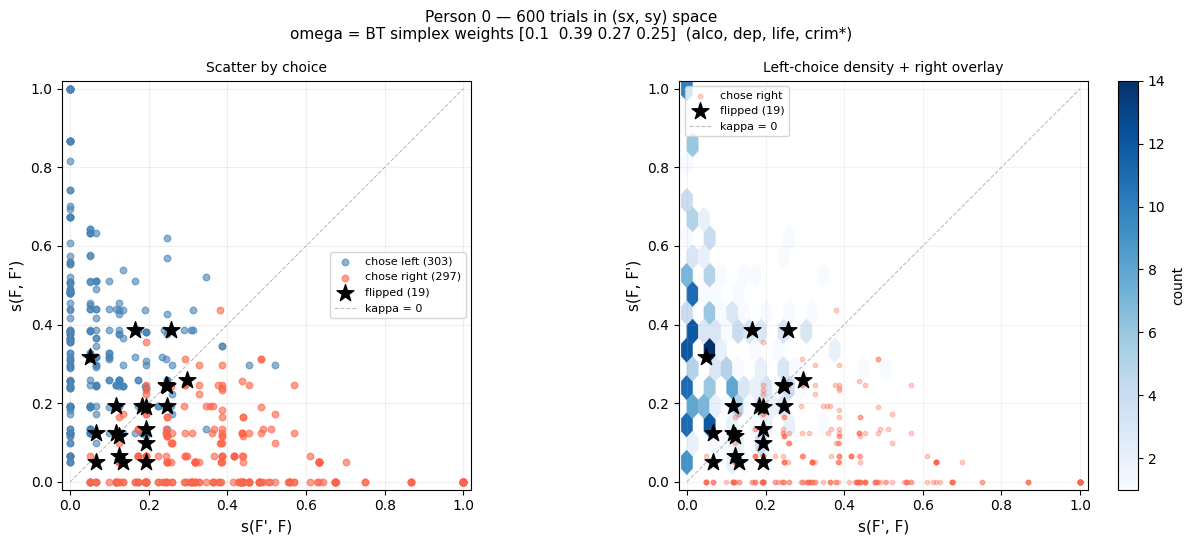

Saved bt_sx_sy.png
mean |kappa| on flipped queries: 0.0701


In [10]:
# ── (sx, sy) scatter using BT simplex-projected weights ─────────────────────
# Use beta2_norm as omega; c_bt already has alco/crim sign-flipped.
# d_bt = |c_bt| = d_full (absolute diffs, sign-flip doesn't change magnitude)

r_bt2  = d_full    @ beta2_norm   # decisiveness under BT weights
k_bt2  = c_bt      @ beta2_norm   # signed preference under BT weights
sx_bt2 = (r_bt2 - k_bt2) / 2
sy_bt2 = (r_bt2 + k_bt2) / 2

# Flipped queries position under BT weights
c_flip_bt  = c_flip_mat * SIGN
r_fbt  = d_flip_mat  @ beta2_norm
k_fbt  = c_flip_bt   @ beta2_norm
sx_fbt = (r_fbt - k_fbt) / 2
sy_fbt = (r_fbt + k_fbt) / 2

left_bt  = y_bt == 1   # chose left
right_bt = y_bt == 0   # chose right

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    'Person 0 — 600 trials in (sx, sy) space\n'
    'omega = BT simplex weights {}  (alco, dep, life, crim*)'.format(np.round(beta2_norm, 2)),
    fontsize=11)

# Left panel: scatter by choice
axes[0].scatter(sx_bt2[left_bt],  sy_bt2[left_bt],  c='steelblue', s=22, alpha=0.6,
                label='chose left ({})'.format(left_bt.sum()))
axes[0].scatter(sx_bt2[right_bt], sy_bt2[right_bt], c='tomato',    s=22, alpha=0.6,
                label='chose right ({})'.format(right_bt.sum()))
axes[0].scatter(sx_fbt, sy_fbt, marker='*', s=160, c='black', zorder=5,
                label='flipped ({})'.format(len(sx_fbt)))
axes[0].plot([0, 1], [0, 1], 'gray', ls='--', lw=0.8, alpha=0.5, label='kappa = 0')
axes[0].set_xlim(-0.02, 1.02); axes[0].set_ylim(-0.02, 1.02)
axes[0].set_aspect('equal')
axes[0].set_xlabel("s(F', F)", fontsize=11)
axes[0].set_ylabel("s(F, F')", fontsize=11)
axes[0].set_title('Scatter by choice', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# Right panel: density (hexbin) left only — reuse existing style
hb = axes[1].hexbin(sx_bt2[left_bt], sy_bt2[left_bt], gridsize=18,
                    cmap='Blues', mincnt=1, linewidths=0.3)
plt.colorbar(hb, ax=axes[1], label='count')
axes[1].scatter(sx_bt2[right_bt], sy_bt2[right_bt], c='tomato', s=10, alpha=0.3,
                label='chose right')
axes[1].scatter(sx_fbt, sy_fbt, marker='*', s=160, c='black', zorder=5,
                label='flipped ({})'.format(len(sx_fbt)))
axes[1].plot([0, 1], [0, 1], 'gray', ls='--', lw=0.8, alpha=0.5, label='kappa = 0')
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)
axes[1].set_aspect('equal')
axes[1].set_xlabel("s(F', F)", fontsize=11)
axes[1].set_ylabel("s(F, F')", fontsize=11)
axes[1].set_title('Left-choice density + right overlay', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('bt_sx_sy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bt_sx_sy.png')
print(f'mean |kappa| on flipped queries: {np.abs(k_fbt).mean():.4f}')
